In [2]:
import pandas as pd
import numpy as np

print("Hello Fraud Detection")

Hello Fraud Detection


In [3]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


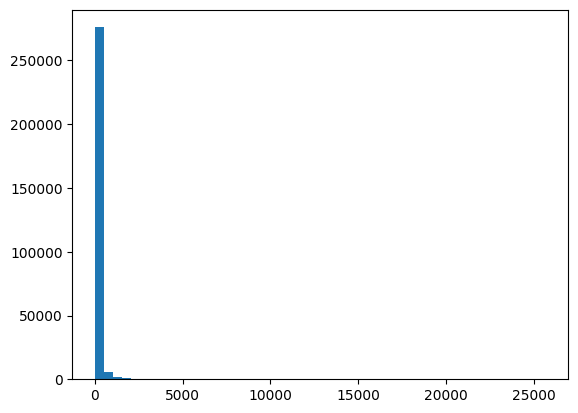

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["Amount"], bins=50)
plt.show()

In [10]:
fraud_df = df[df["Class"] == 1]

fraud_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


In [11]:
df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [12]:
import numpy as np
import pandas as pd

# 再現性固定
rng = np.random.default_rng(42)

# df が既に読み込まれている前提
df_enriched = df.copy()

n = len(df_enriched)
is_fraud = df_enriched["Class"].eq(1).to_numpy()

# 1. customer_id：正常は広く、不正は一部顧客にやや集中
df_enriched["customer_id"] = np.where(
    is_fraud,
    rng.integers(1, 8000, n),
    rng.integers(1, 50000, n)
)

# 2. merchant_id：不正は一部の高リスク加盟店にやや集中
df_enriched["merchant_id"] = np.where(
    is_fraud,
    rng.choice([f"M{str(i).zfill(5)}" for i in range(1, 1500)], n),
    rng.choice([f"M{str(i).zfill(5)}" for i in range(1, 20000)], n)
)

# 3. country：正常はJP中心、不正は海外比率高め
df_enriched["country"] = np.where(
    is_fraud,
    rng.choice(["JP", "US", "SG", "CN", "VN", "HK"], n, p=[0.35, 0.22, 0.16, 0.12, 0.08, 0.07]),
    rng.choice(["JP", "US", "SG", "CN", "VN", "HK"], n, p=[0.92, 0.03, 0.02, 0.01, 0.01, 0.01])
)

# 4. channel：不正はEC比率高め
df_enriched["channel"] = np.where(
    is_fraud,
    rng.choice(["EC", "POS", "ATM"], n, p=[0.78, 0.18, 0.04]),
    rng.choice(["EC", "POS", "ATM"], n, p=[0.28, 0.68, 0.04])
)

# 5. entry_mode：不正は手入力・カード非提示寄り
df_enriched["entry_mode"] = np.where(
    is_fraud,
    rng.choice(["chip", "contactless", "manual", "card_not_present"], n, p=[0.08, 0.12, 0.24, 0.56]),
    rng.choice(["chip", "contactless", "manual", "card_not_present"], n, p=[0.42, 0.32, 0.04, 0.22])
)

# 6. merchant_category：不正はGaming/Luxury/Travel/Digital Goodsに寄せる
df_enriched["merchant_category"] = np.where(
    is_fraud,
    rng.choice(
        ["grocery", "restaurant", "travel", "gaming", "luxury", "digital_goods", "electronics"],
        n,
        p=[0.04, 0.06, 0.20, 0.22, 0.18, 0.20, 0.10]
    ),
    rng.choice(
        ["grocery", "restaurant", "travel", "gaming", "luxury", "digital_goods", "electronics"],
        n,
        p=[0.28, 0.30, 0.10, 0.05, 0.04, 0.08, 0.15]
    )
)

# 7. device_id：不正は新しめ・使い捨て端末っぽく多様にする
df_enriched["device_id"] = np.where(
    is_fraud,
    rng.choice([f"D{str(i).zfill(6)}" for i in range(1, 80000)], n),
    rng.choice([f"D{str(i).zfill(6)}" for i in range(1, 35000)], n)
)

# 8. is_new_device：不正は新規端末率高め
df_enriched["is_new_device"] = np.where(
    is_fraud,
    rng.choice([0, 1], n, p=[0.28, 0.72]),
    rng.choice([0, 1], n, p=[0.88, 0.12])
)

# 9. authentication_result：不正は認証失敗/未実施が多め
df_enriched["authentication_result"] = np.where(
    is_fraud,
    rng.choice(["success", "failed", "not_required"], n, p=[0.48, 0.30, 0.22]),
    rng.choice(["success", "failed", "not_required"], n, p=[0.90, 0.04, 0.06])
)

# 10. customer_tenure_months：不正は比較的新規会員に寄せる
df_enriched["customer_tenure_months"] = np.where(
    is_fraud,
    rng.integers(0, 24, n),
    rng.integers(3, 120, n)
)

# 追加で便利な派生フラグ
df_enriched["is_foreign"] = (df_enriched["country"] != "JP").astype(int)
df_enriched["is_ec"] = (df_enriched["channel"] == "EC").astype(int)
df_enriched["is_high_risk_category"] = df_enriched["merchant_category"].isin(
    ["gaming", "luxury", "digital_goods", "travel"]
).astype(int)

# 確認
print(df_enriched.shape)
display(df_enriched.head())

# 不正/正常で付与カラムの偏り確認
check_cols = [
    "country", "channel", "entry_mode", "merchant_category",
    "is_new_device", "authentication_result"
]

for col in check_cols:
    print(f"\n===== {col} =====")
    display(pd.crosstab(df_enriched[col], df_enriched["Class"], normalize="columns"))

(284807, 44)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,channel,entry_mode,merchant_category,device_id,is_new_device,authentication_result,customer_tenure_months,is_foreign,is_ec,is_high_risk_category
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,POS,contactless,grocery,D018958,0,success,58,0,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,POS,card_not_present,restaurant,D029955,0,success,33,0,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,POS,contactless,grocery,D003767,0,success,24,0,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,POS,chip,digital_goods,D018370,0,success,97,0,0,1
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,POS,chip,digital_goods,D008843,0,success,59,0,0,1



===== country =====


Class,0,1
country,,
CN,0.009641,0.117886
HK,0.009869,0.071138
JP,0.920187,0.361789
SG,0.020168,0.142276
US,0.030016,0.231707
VN,0.010119,0.075203



===== channel =====


...

Class,0,1
merchant_category,,
digital_goods,0.080745,0.211382
electronics,0.149299,0.077236
gaming,0.049382,0.245935
grocery,0.281364,0.044715
luxury,0.040156,0.154472
restaurant,0.300519,0.083333
travel,0.098535,0.182927



===== is_new_device =====


Class,0,1
is_new_device,,
0,0.880495,0.280488
1,0.119505,0.719512



===== authentication_result =====


Class,0,1
authentication_result,,
failed,0.039411,0.304878
not_required,0.060686,0.207317
success,0.899903,0.487805


In [13]:
pd.crosstab(
    df_enriched["is_foreign"],
    df_enriched["Class"],
    normalize="columns"
)

Class,0,1
is_foreign,,
0,0.920187,0.361789
1,0.079813,0.638211


In [14]:
pd.crosstab(
    df_enriched["is_ec"],
    df_enriched["Class"],
    normalize="columns"
)

Class,0,1
is_ec,,
0,0.718545,0.25
1,0.281455,0.75


In [15]:
pd.crosstab(
    df_enriched["is_new_device"],
    df_enriched["Class"],
    normalize="columns"
)

Class,0,1
is_new_device,,
0,0.880495,0.280488
1,0.119505,0.719512


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import pandas as pd
import numpy as np

# 目的変数
y = df_enriched["Class"]

# 使う特徴量
numeric_features = [
    "Time", "Amount",
    *[f"V{i}" for i in range(1, 29)],
    "customer_tenure_months",
    "is_new_device",
    "is_foreign",
    "is_ec",
    "is_high_risk_category"
]

categorical_features = [
    "country",
    "channel",
    "entry_mode",
    "merchant_category",
    "authentication_result"
]

X = df_enriched[numeric_features + categorical_features]

# 時系列っぽく分割：後半20%をテストにする
split_idx = int(len(df_enriched) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# カテゴリ変数をOne-Hot化
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# 不正が少ないので重み調整
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight=None,
    scale_pos_weight=scale_pos_weight
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

pipeline.fit(X_train, y_train)

# 予測
y_proba = pipeline.predict_proba(X_test)[:, 1]

# いったん閾値0.5
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

# 評価
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 417, number of negative: 227428
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7824
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001830 -> initscore=-6.301503
[LightGBM] [Info] Start training from score -6.301503
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/Users/odaju/fraud-detection-project/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [17]:
thresholds = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

results = []

for th in thresholds:
    pred = (y_proba >= th).astype(int)
    results.append({
        "threshold": th,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "alert_count": pred.sum()
    })

pd.DataFrame(results)

,threshold,precision,recall,f1,alert_count
0,0.01,0.071511,0.826667,0.131635,867
1,0.03,0.071511,0.826667,0.131635,867
2,0.05,0.071511,0.826667,0.131635,867
3,0.10,0.071511,0.826667,0.131635,867
4,0.20,0.071511,0.826667,0.131635,867
5,0.30,0.071511,0.826667,0.131635,867
6,0.50,0.071511,0.826667,0.131635,867


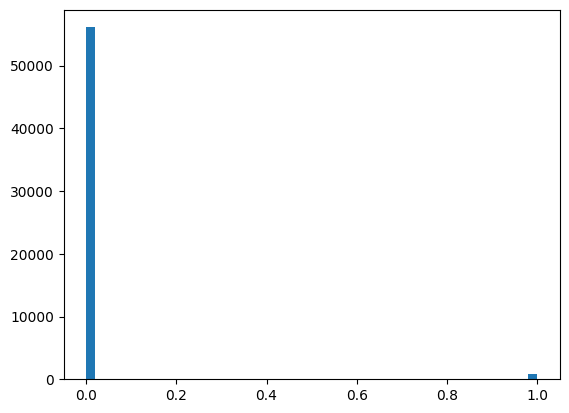

In [18]:
import matplotlib.pyplot as plt

plt.hist(y_proba, bins=50)
plt.show()

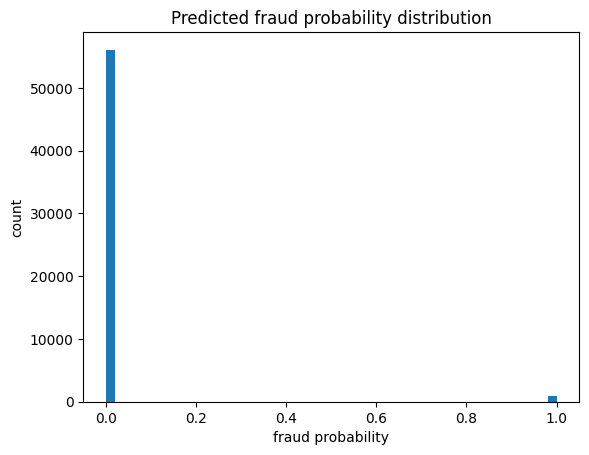

count    56962.000000
mean         0.015221
std          0.122431
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
dtype: float64

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

plt.hist(y_proba, bins=50)
plt.title("Predicted fraud probability distribution")
plt.xlabel("fraud probability")
plt.ylabel("count")
plt.show()

pd.Series(y_proba).describe()

In [20]:
# OneHot後の特徴量名を取得
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

# LightGBM本体
lgbm_model = pipeline.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(30)

,feature,importance
41,num__V17,180
28,num__V4,165
25,num__V1,149
42,num__V18,133
26,num__V2,129
36,num__V12,122
46,num__V22,122
32,num__V8,113
34,num__V10,113
48,num__V24,106


/Users/odaju/fraud-detection-project/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


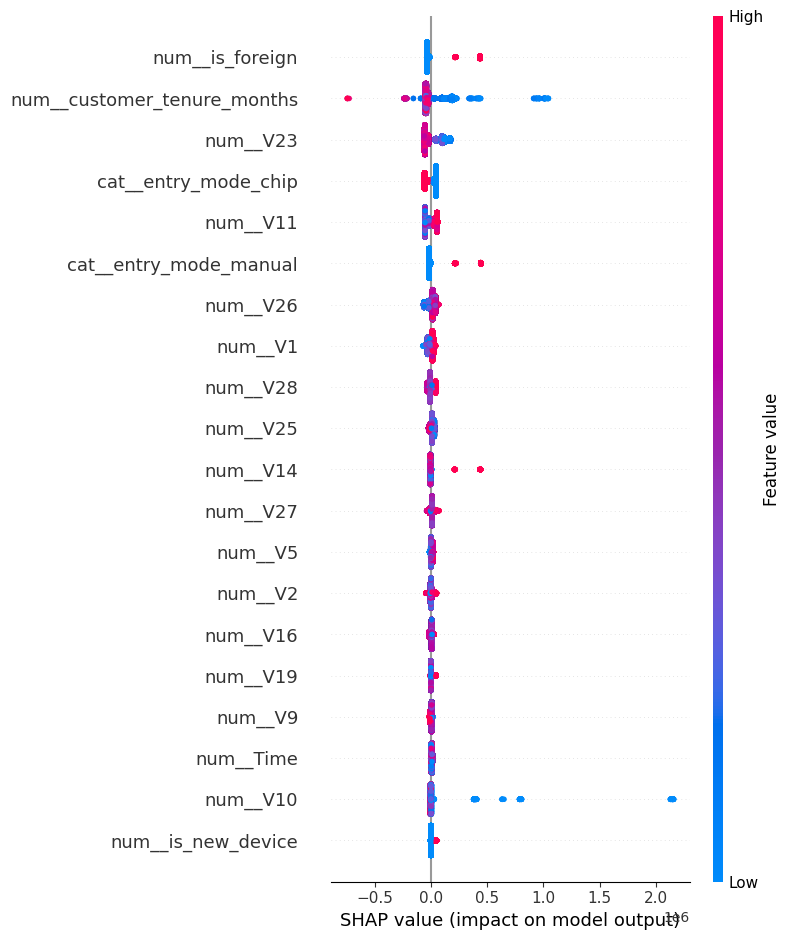

In [21]:
import shap

# 前処理後データ
X_test_transformed = pipeline.named_steps["preprocess"].transform(X_test)

# SHAP explainer
explainer = shap.TreeExplainer(lgbm_model)

# shap values
shap_values = explainer.shap_values(X_test_transformed)

# summary plot
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

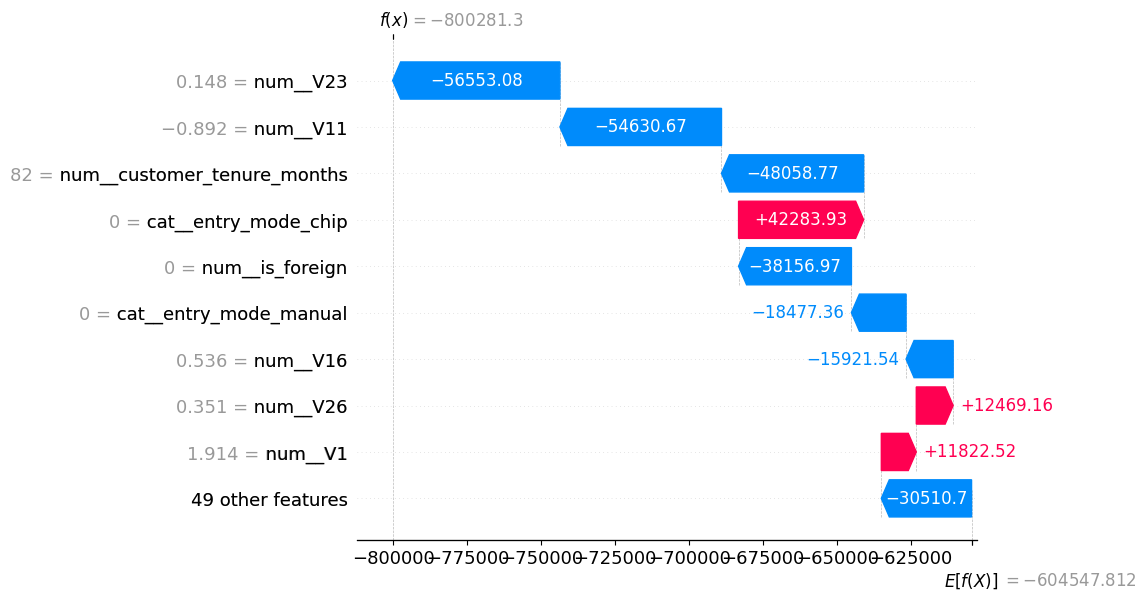

In [22]:
idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[idx],
        feature_names=feature_names
    )
)

In [23]:
top_idx = np.argmax(y_proba)

top_idx

np.int64(360)

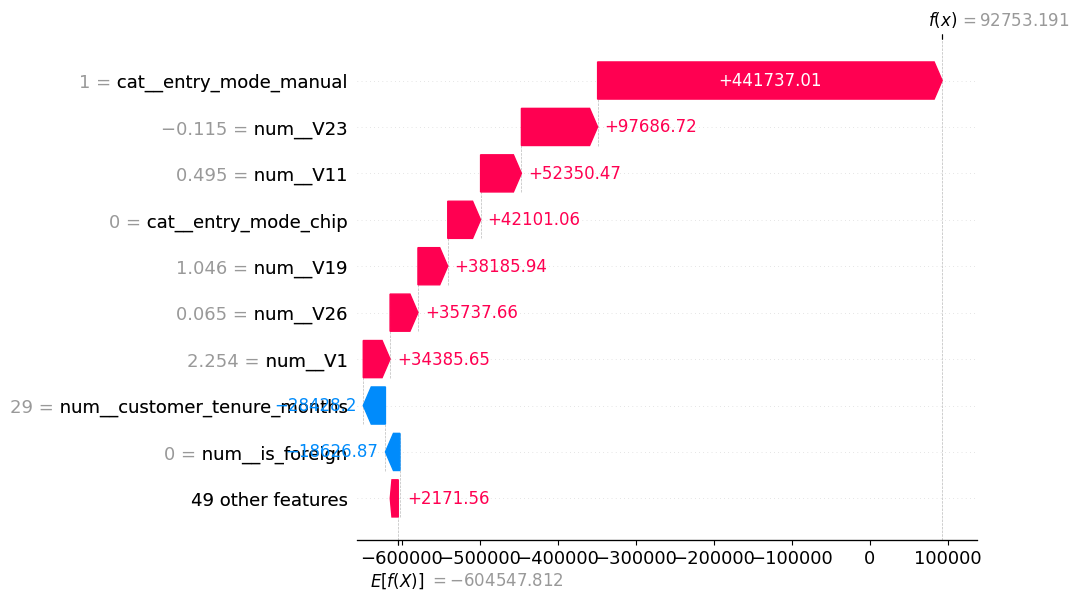

In [24]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[top_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[top_idx],
        feature_names=feature_names
    )
)

False Positive件数: 805
対象index: 360
予測確率: 1.0


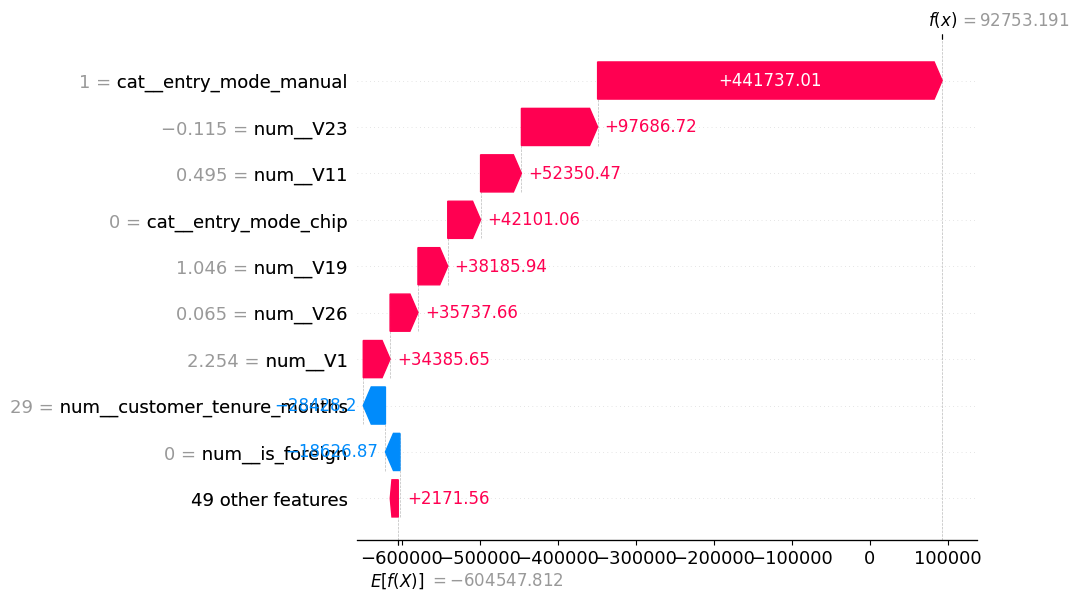

In [29]:
# 誤検知（False Positive）を取得
fp_idx = np.where((y_pred == 1) & (y_test.values == 0))[0]

print("False Positive件数:", len(fp_idx))

# 最初のFP案件
idx = fp_idx[0]

print("対象index:", idx)
print("予測確率:", y_proba[idx])

# waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[idx],
        feature_names=feature_names
    )
)

In [30]:
fn_idx = np.where((y_pred == 0) & (y_test.values == 1))[0]

対象index: 2231
予測確率: 0.0


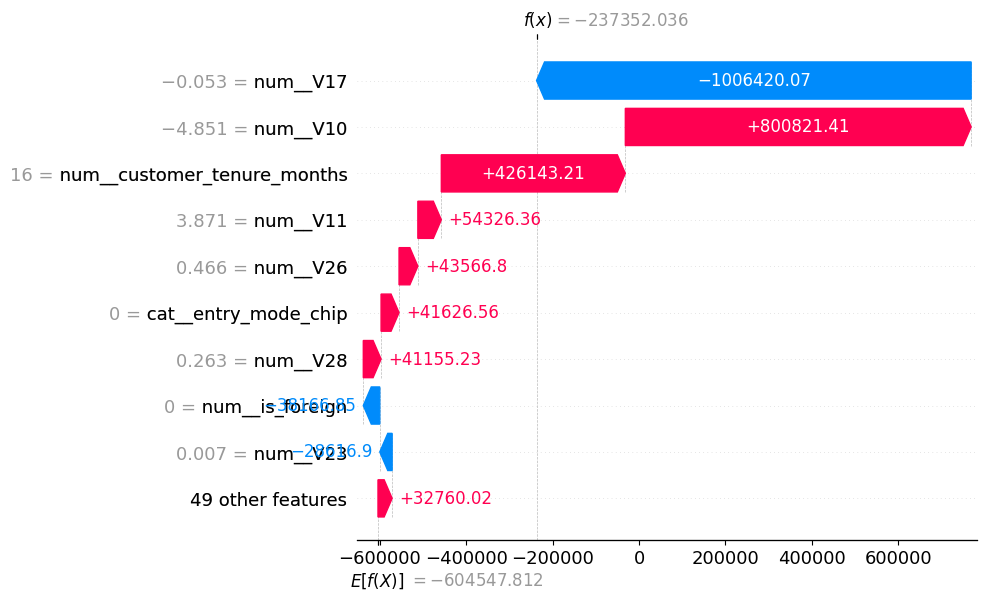

In [32]:


# 最初のFP案件
idx = fn_idx[0]

print("対象index:", idx)
print("予測確率:", y_proba[idx])

# waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[idx],
        feature_names=feature_names
    )
)

In [33]:
# テストデータに予測結果を付与
df_result = X_test.copy()
df_result["actual_class"] = y_test.values
df_result["fraud_score"] = y_proba
df_result["predicted_class"] = y_pred

# 見やすいラベル
df_result["actual_label"] = df_result["actual_class"].map({0: "normal", 1: "fraud"})
df_result["predicted_label"] = df_result["predicted_class"].map({0: "normal", 1: "fraud"})

# 審査理由を簡易生成
def generate_rule_reason(row):
    reasons = []
    
    if row.get("is_foreign", 0) == 1:
        reasons.append("海外取引")
    if row.get("is_ec", 0) == 1:
        reasons.append("EC取引")
    if row.get("is_new_device", 0) == 1:
        reasons.append("新規端末")
    if row.get("is_high_risk_category", 0) == 1:
        reasons.append("高リスクカテゴリ")
    if row.get("customer_tenure_months", 999) < 24:
        reasons.append("利用期間が短い")
    if row.get("authentication_result") in ["failed", "not_required"]:
        reasons.append("認証リスクあり")
    
    return " / ".join(reasons) if reasons else "明確な業務ルール上のリスクは小さい"

df_result["rule_reason"] = df_result.apply(generate_rule_reason, axis=1)

# リスク帯
df_result["risk_band"] = pd.cut(
    df_result["fraud_score"],
    bins=[-0.001, 0.1, 0.5, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Critical"]
)

df_result.sort_values("fraud_score", ascending=False).head(20)

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,entry_mode,merchant_category,authentication_result,actual_class,fraud_score,predicted_class,actual_label,predicted_label,rule_reason,risk_band
238671,149767.0,16.73,-0.856709,1.429659,0.249752,0.758737,0.787393,-0.181738,1.000170,0.359330,...,manual,gaming,success,0,1.0,1,normal,fraud,高リスクカテゴリ,Critical
253576,156319.0,8.98,-0.576286,1.120477,-0.201433,-0.568384,0.033348,-1.162879,0.588705,0.190979,...,contactless,luxury,success,0,1.0,1,normal,fraud,海外取引 / EC取引 / 高リスクカテゴリ / 利用期間が短い,Critical
271572,164637.0,35.75,-0.029728,0.917382,0.337105,0.680406,0.580832,0.667974,0.689782,0.022347,...,chip,grocery,failed,0,1.0,1,normal,fraud,海外取引 / 認証リスクあり,Critical
269389,163645.0,69.99,-0.780132,0.106165,0.548875,-2.187145,-0.086066,-0.183342,0.097083,0.231505,...,contactless,grocery,success,0,1.0,1,normal,fraud,海外取引 / 新規端末 / 利用期間が短い,Critical
255403,157207.0,4.97,1.170756,2.501038,-4.986159,5.374160,0.997798,-1.259004,-1.237689,0.358426,...,card_not_present,travel,success,1,1.0,1,fraud,fraud,海外取引 / EC取引 / 新規端末 / 高リスクカテゴリ / 利用期間が短い,Critical
250304,154833.0,14.90,2.059194,0.075138,-2.056926,0.162159,0.635543,-1.125874,0.657335,-0.380731,...,chip,grocery,success,0,1.0,1,normal,fraud,海外取引 / 利用期間が短い,Critical
248334,153895.0,119.42,1.908935,-1.401036,-0.572878,-0.946467,-1.117714,-0.009234,-1.131510,0.112235,...,contactless,restaurant,success,0,1.0,1,normal,fraud,海外取引 / 利用期間が短い,Critical
283648,171763.0,261.65,-1.277515,0.742478,0.742430,-0.807453,-0.602637,1.466955,1.063692,0.531380,...,card_not_present,digital_goods,success,0,1.0,1,normal,fraud,海外取引 / 新規端末 / 高リスクカテゴリ / 利用期間が短い,Critical
259488,159137.0,0.76,-0.820996,1.978742,-1.139187,0.171820,1.584531,-0.855897,1.198131,0.229135,...,card_not_present,grocery,success,0,1.0,1,normal,fraud,海外取引,Critical
271552,164627.0,3.91,-1.984442,1.461176,-0.578198,-1.153886,1.875830,0.447608,0.884280,0.510124,...,manual,restaurant,success,0,1.0,1,normal,fraud,利用期間が短い,Critical


In [34]:
df_result.to_csv("fraud_detection_result.csv", index=False)
print("saved: fraud_detection_result.csv")

saved: fraud_detection_result.csv


In [35]:
# SHAP値DataFrame化
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)

# 各行のSHAP重要特徴を取得
top_features_list = []

for i in range(len(shap_df)):
    
    row_shap = shap_df.iloc[i]

    # 絶対値順で上位
    top_features = (
        row_shap.abs()
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

    top_features_list.append(top_features)

# 保存
df_result = df_result.reset_index(drop=True)

df_result["top_shap_features"] = [
    ", ".join(features)
    for features in top_features_list
]

df_result.head()

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,merchant_category,authentication_result,actual_class,fraud_score,predicted_class,actual_label,predicted_label,rule_reason,risk_band,top_shap_features
0,145248.0,50.00,1.914027,-0.490068,-0.326111,0.604711,-0.850136,-0.736319,-0.524058,-0.088614,...,electronics,success,0,0.0,0,normal,normal,明確な業務ルール上のリスクは小さい,Low,"num__V23, num__V11, num__customer_tenure_month..."
1,145249.0,14.95,2.152696,-0.036161,-2.231811,0.091766,0.537612,-1.368103,0.613327,-0.455252,...,restaurant,success,0,0.0,0,normal,normal,明確な業務ルール上のリスクは小さい,Low,"num__V23, cat__entry_mode_chip, num__V11, num_..."
2,145249.0,7.70,-4.034795,2.305079,-1.461693,-0.729887,-1.528750,-1.225679,-0.893354,1.622522,...,electronics,success,0,0.0,0,normal,normal,明確な業務ルール上のリスクは小さい,Low,"num__V23, num__customer_tenure_months, num__V1..."
3,145249.0,6.99,-1.668741,1.168055,0.249642,-1.268497,0.785923,-0.663959,0.859433,0.068111,...,grocery,success,0,0.0,0,normal,normal,明確な業務ルール上のリスクは小さい,Low,"num__V23, num__V11, num__is_foreign, num__V26,..."
4,145250.0,460.71,-0.550678,-0.429004,-1.291893,-0.414409,-0.292229,0.071843,2.426068,-0.212730,...,grocery,success,0,0.0,0,normal,normal,明確な業務ルール上のリスクは小さい,Low,"num__V23, cat__entry_mode_chip, num__customer_..."


In [36]:
def generate_shap_reason(row):
    
    feature_text = row["top_shap_features"]

    return f"""
モデルは主に以下の特徴を重視しました:
{feature_text}
"""

df_result["shap_reason"] = df_result.apply(generate_shap_reason, axis=1)

In [37]:
df_result.to_csv("fraud_detection_result.csv", index=False)

In [38]:
# SHAP値を保存：テストデータの各行 × 各特徴量
shap_values_df = pd.DataFrame(shap_values, columns=feature_names)

# df_result と同じ行番号で合わせる
shap_values_df = shap_values_df.reset_index(drop=True)
df_result = df_result.reset_index(drop=True)

# 保存
shap_values_df.to_csv("shap_values.csv", index=False)
df_result.to_csv("fraud_detection_result.csv", index=False)

print("saved: fraud_detection_result.csv")
print("saved: shap_values.csv")

saved: fraud_detection_result.csv
saved: shap_values.csv
